# Ba8Ga16Ge30：从分子动力学快照拟合声子模型

读取 300 K 分子动力学轨迹中的位置和力，联合拟合 FC2、FC3，再用二阶部分画出声子谱。这个案例说明已有轨迹怎样变成 MLFCS 的训练数据。

数据沿用 hiPhive 笼形材料热导率示例，重用时请保留上游归属和许可条款。原胞有 54 个原子，计算比 Si 案例更大，建议与其他 notebook 串行运行。环境见[教程总览](index.md)。

## 1. 读取参考原胞和超胞

训练数据来自 $2\times2\times2$、432 原子的超胞。先读理想参考结构，后面的位移以它为零点；不能把任意一帧热运动构型当作理想超胞替代。

换自己的轨迹时，要配套准备参考晶胞、理想超胞和带力轨迹，并保持晶胞和原子顺序一致。

In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
from ase.io import read, iread
from mlfcs import ClusterSpace, ClusterMap, ForceDataset, FitSystem
from mlfcs.phonon import Harmonic

logging.getLogger("mlfcs").setLevel(logging.WARNING)
DATA = Path("data/ba8ga16ge30")
if not DATA.exists():
    DATA = Path("docs/notebooks") / DATA
primitive = read(DATA / "primitive.vasp")
supercell = read(DATA / "supercell.vasp")
print(f"原胞：{len(primitive)} 原子；超胞：{len(supercell)} 原子")

原胞：54 原子；超胞：432 原子


## 2. 先确定拟合哪些相互作用

二阶截断取 5.4 Å、三阶取 4.35 Å，沿用这份教学数据的局域模型；越高阶限制得越短，可控制参数规模。`max_body_orders={2: 2, 3: 2}` 还限制三阶最多涉及两个不同原子位置，允许重复指标，但排除三个不同位置的相互作用。

`asr=True` 使拟合直接在平移不变的子空间中进行。`symprec=1e-4` Å 用于容纳输入结构的几何精度；它不是力拟合容差。质量从 ASE 参考结构读取，用于后面的声子计算。

这些设置是演示起点，换材料时应重新选择截断、体阶与对称容差。

In [2]:
space = ClusterSpace(
    primitive, cutoffs={2: 5.4, 3: 4.35}, max_body_orders={2: 2, 3: 2},
    symprec=1e-4, asr=True,
)
print(f"物理参数：{space.n_parameters}；ASR 自由参数：{space.n_free_parameters}")

物理参数：8329；ASR 自由参数：3412


## 3. 将模型放进训练超胞

`ClusterMap` 从两份晶胞推断整数超胞矩阵，并把参考晶格上的相互作用对应到超胞原子。先检查结构可辨识性：即使有许多训练帧，太小的超胞也可能无法区分不同参数。

本例直接使用数据附带的超胞，不重新生成或重排原子。

In [3]:
mapping = ClusterMap(space, supercell)
mapping.rank_info().require_full()
print("超胞可以区分所选模型的全部物理参数")

超胞可以区分所选模型的全部物理参数


## 4. 从轨迹收集位移和力

`nve.extxyz` 中的每帧已经带有力。`iread` 逐帧读取结构，`ForceDataset` 收集相对于参考超胞的最小像位移与目标力；它不会启动分子动力学或重新计算力。

这些数组仍然保存在内存中，并非磁盘上的流式数据集。模型来自 300 K 采样分布，因此其二阶部分是该拟合模型的有效谐波项，不能直接称为独立计算的 0 K 裸 FC2。

In [4]:
dataset = ForceDataset(mapping, iread(DATA / "nve.extxyz", index=":"))
print(f"带力训练样本：{len(dataset.forces)} 帧")

带力训练样本：101 帧


## 5. 联合拟合 FC2 和 FC3

正规表示逐帧累积最小二乘统计量，不保留完整设计矩阵，适合这里较多的力方程。它仍需参数平方规模的内存；初次运行会等待方程构造完成。

保留默认求解容差，将最大迭代数提高到 10000，为较大的模型预留收敛空间。这个上限不是训练步数，也不会改变样本数。

训练 RMSE 与相对误差用于检查本模型能否解释这批力。泛化精度还需要独立轨迹验证。

In [5]:
system = FitSystem(dataset, representation="normal")
model = system.solve(maxiter=10_000)
print(f"力 RMSE：{system.rmse(model):.5f} eV/Å")
print(f"力相对误差：{system.relative_error(model):.3%}")

力 RMSE：0.02177 eV/Å
力相对误差：5.137%


## 6. 查看有效 FC2 的声子谱

联合拟合结果包含二阶、三阶；`Harmonic` 取其中的 FC2 计算频率。54 原子原胞每个 q 点有 162 个模式。

`run_band_path(npoints=200)` 由 ASE 按原胞晶胞生成默认路径。200 是绘图采样数，不是倒空间积分网格；跨点没有模式追踪，负频率表示虚频。

路径：GLB1,BZGX,QFP1Z,LP；模式数：162


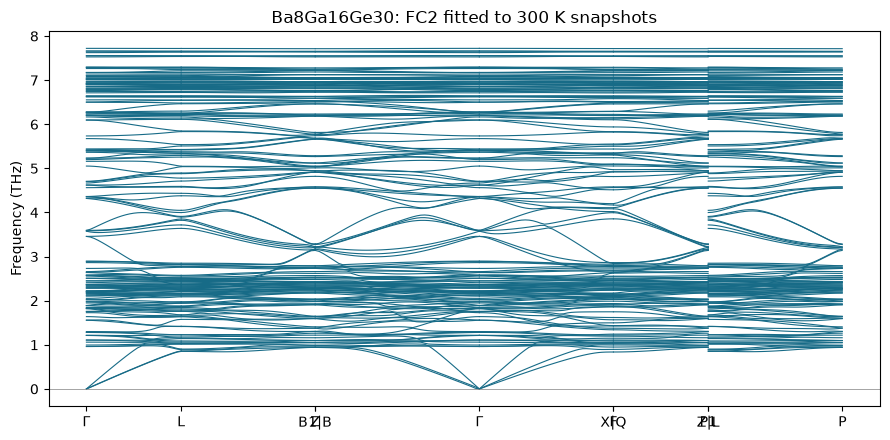

In [6]:
bands = Harmonic(model).run_band_path(npoints=200)
print(f"路径：{bands.path}；模式数：{bands.frequencies_thz.shape[1]}")
fig, axis = plt.subplots(figsize=(9, 4.5))
for segment in bands.segments:
    axis.plot(bands.distances[segment], bands.frequencies_thz[segment], color="#176b87", lw=0.8)
axis.set_xticks(bands.tick_positions, bands.tick_labels)
axis.axhline(0, color="0.5", lw=0.5)
axis.set_ylabel("Frequency (THz)")
axis.set_title("Ba8Ga16Ge30: FC2 fitted to 300 K snapshots")
fig.tight_layout()
plt.show()

## 接下来

我们把一条已有带力轨迹转换成数据集，联合恢复 FC2、FC3，并检查了二阶模型的声子谱。图与训练误差是起点，不是热导率或实验声子谱的验证。

换材料时，优先替换参考结构、超胞与轨迹，再调整 cutoff、最大体阶和对称容差。若需要保存模型，可使用 `model.save(...)`；导出接口见[拟合](../fitting-api.md)。

下一份 [Si 联合拟合教程](si-fitting.ipynb)扩展到 FC2–FC5，并展示怎样将 FC2、FC3 交给 phono3py 计算热导率。